# Análisis de resultados: predicción conforme con abstención en AI4I 2020

Este notebook lee la ejecución guardada en `artifacts/run_2026-09-11_seed42`, muestra sus
tablas y figuras, recorre a mano el cálculo del cuantil conforme y verifica que las
métricas del informe se reconstruyen desde las probabilidades exportadas. No entrena
nada: la ejecución se reproduce con

```bash
uv sync --extra torch
uv run python -m conformal_fault_inference_with_abstention --output artifacts/run_2026-09-11_seed42 --overwrite
```

Las figuras nuevas que genera este notebook se guardan en `artifacts/<ejecución>/figures/`.
El análisis escrito está en [RESULTADOS.md](../RESULTADOS.md).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.precision", 4)

ROOT = Path.cwd() if (Path.cwd() / "artifacts").exists() else Path.cwd().parent
RUN = ROOT / "artifacts" / "run_2026-09-11_seed42"
FIG = RUN / "figures"
assert RUN.exists(), f"No existe {RUN}; ejecuta primero el pipeline."
print("Ejecución:", RUN.relative_to(ROOT))

Ejecución: artifacts\run_2026-09-11_seed42


## 1. Entorno y configuración de la ejecución

In [2]:
manifest = json.loads((RUN / "run_manifest.json").read_text(encoding="utf-8"))
print("SHA-256 del CSV:", manifest["data_sha256"])
print("Filas originales / etiquetadas / excluidas:", manifest["n_raw_rows"], manifest["n_labeled_rows"], manifest["n_excluded_rows"])
pd.Series(manifest["versions"]).to_frame("versión")

SHA-256 del CSV: ffc3c28f35b1a1636eacd2bf46aca0ff5e795b4a8eb934309c5819079e9b5a18
Filas originales / etiquetadas / excluidas: 10000 9973 27


,versión
python,3.13.5
platform,Windows-11-10.0.26200-SP0
numpy,2.5.3
pandas,3.0.5
scikit-learn,1.9.0
matplotlib,3.11.1
package,0.1.0
torch,2.11.0+cu128
cuda_available,True
cuda_version,12.8


In [3]:
pd.Series(manifest["config"]).to_frame("valor")

,valor
data_path,data\raw\ai4i2020.csv
output_dir,artifacts\run_2026-09-11_seed42
label_policy,"{'priority': ['TWF', 'PWF', 'OSF', 'HDF'], 'rn..."
calibration_size,0.3
test_size,0.2
alphas,"[0.05, 0.1, 0.2]"
random_state,42
models,"[hgb, mlp]"
mlp_hidden,"[64, 64]"
mlp_epochs,200


## 2. Auditoría, conteos y viabilidad de calibración

In [4]:
pd.read_csv(RUN / "audit.csv").set_index("metric")

,count
metric,
rows,10000
machine_failure,339
flag_TWF,46
flag_HDF,115
flag_PWF,95
flag_OSF,98
flag_RNF,19
rows_with_physical_mode,330
rows_with_multiple_physical_modes,23


In [5]:
pd.read_csv(RUN / "class_counts.csv", index_col=0)

,train,calibration,test,total
class,,,,
Normal,4821,2893,1929,9643
TWF,23,14,9,46
HDF,53,32,21,106
PWF,47,28,19,94
OSF,42,25,17,84


In [6]:
feasibility = pd.read_csv(RUN / "calibration_feasibility.csv", index_col=0)
feasibility.pivot_table(index=feasibility.index, columns="alpha", values=["rank", "finite_threshold_possible"], aggfunc="first")

finite_threshold_possible              rank            
alpha                       0.05  0.10  0.20  0.05  0.10  0.20
class                                                         
HDF                         True  True  True    32    30    27
Normal                      True  True  True  2750  2605  2316
OSF                         True  True  True    25    24    21
PWF                         True  True  True    28    27    24
TWF                        False  True  True    15    14    12

## 3. El cuantil conforme a mano

La puntuación de no conformidad es `s(x, y) = 1 − p(y | x)`. Con `n` puntuaciones de
calibración, el umbral es la puntuación de rango `⌈(n + 1)(1 − α)⌉`, sin interpolación.
Si ese rango supera `n`, el umbral es infinito y la clase entra en todos los conjuntos.
El ejemplo usa probabilidades inventadas para ver cada paso.

In [7]:
from conformal_fault_inference_with_abstention.conformal import MondrianConformal, SplitConformal, conformal_quantile, conformal_rank
from conformal_fault_inference_with_abstention.decision import route_predictions
from conformal_fault_inference_with_abstention.evaluation import evaluate_sets
from conformal_fault_inference_with_abstention.scores import true_label_scores

classes = np.array(["Normal", "TWF"])
proba_cal = np.array([[0.875, 0.125], [0.75, 0.25], [0.5, 0.5], [0.9, 0.1], [0.3, 0.7]])
y_cal = np.array(["Normal", "Normal", "TWF", "Normal", "TWF"])

scores = true_label_scores(proba_cal, y_cal, classes=classes)
alpha = 0.4
n = len(scores)
print("puntuaciones de la etiqueta verdadera:", scores)
print("ordenadas:", np.sort(scores))
print(f"n = {n}, rango = ceil(({n} + 1) * (1 - {alpha})) = {conformal_rank(n, alpha=alpha)}")
print("umbral:", conformal_quantile(scores, alpha=alpha))

puntuaciones de la etiqueta verdadera: [0.125 0.25  0.5   0.1   0.3  ]
ordenadas: [0.1   0.125 0.25  0.3   0.5  ]
n = 5, rango = ceil((5 + 1) * (1 - 0.4)) = 4
umbral: 0.30000000000000004


In [8]:
split = SplitConformal(alpha=alpha).calibrate(proba_cal, y_cal, classes=classes)
proba_test = np.array([[0.8, 0.2], [0.55, 0.45], [0.05, 0.95], [0.5, 0.5]])
sets = split.predict_set(proba_test, classes=classes)
pd.DataFrame({
    "p_Normal": proba_test[:, 0], "p_TWF": proba_test[:, 1],
    "en_conjunto": [", ".join(classes[row]) or "∅" for row in sets.mask],
    "tamaño": sets.mask.sum(axis=1), "vía": route_predictions(sets),
})

,p_Normal,p_TWF,en_conjunto,tamaño,vía
0,0.80,0.20,Normal,1,automatic
1,0.55,0.45,∅,0,human
2,0.05,0.95,TWF,1,automatic
3,0.50,0.50,∅,0,human


In [9]:
mondrian = MondrianConformal(alpha=alpha).calibrate(proba_cal, y_cal, classes=classes)
print("umbrales Mondrian por clase:", {str(c): float(t) for c, t in zip(classes, mondrian.thresholds_)})
print("  Normal: n = 3, rango", conformal_rank(3, alpha=alpha), "→ puntuación máxima de Normal")
print("  TWF:    n = 2, rango", conformal_rank(2, alpha=alpha), "> 2 → infinito")
report = evaluate_sets(np.array(["Normal", "TWF", "TWF", "Normal"]), mondrian.predict_set(proba_test, classes=classes))
report.by_class

umbrales Mondrian por clase: {'Normal': 0.25, 'TWF': 0.5}
  Normal: n = 3, rango 3 → puntuación máxima de Normal
  TWF:    n = 2, rango 2 > 2 → infinito


,class,support,covered,coverage,mean_set_size,abstention_rate
0,Normal,2,1,0.5,1.0,0.0
1,TWF,2,1,0.5,0.5,0.5


## 4. Métricas globales en prueba

In [10]:
metrics = pd.read_csv(RUN / "metrics.csv")
metrics.set_index(["model", "variant", "alpha"])[["marginal_coverage", "mean_set_size", "abstention_rate", "assisted_rate", "human_rate", "automatic_count", "automatic_errors", "automatic_error_rate"]]

marginal_coverage  mean_set_size  abstention_rate  assisted_rate  human_rate  automatic_count  automatic_errors  automatic_error_rate
model variant  alpha                                                                                                                                       
hgb   split    0.05              0.9544         0.9594           0.0406         0.0000      0.0406             1914                10                0.0052
      mondrian 0.05              0.9589         2.6351           1.0000         0.3729      0.6271                0                 0                   NaN
      split    0.10              0.9093         0.9118           0.0882         0.0000      0.0882             1819                 5                0.0027
      mondrian 0.10              0.9173         1.3238           0.3048         0.2862      0.0185             1387                82                0.0591
      split    0.20              0.8005         0.8010           0.1990         0.0000      0.1990             1598                 1                0.0006
      mondrian 0.20              0.7990         0.8887           0.1464         0.0175      0.1288             1703               133                0.0781
mlp   split    0.05              0.9539         0.9589           0.0411         0.0000      0.0411             1913                10                0.0052
      mondrian 0.05              0.9504         2.0712           0.9739         0.8807      0.0932               52                50                0.9615
      split    0.10              0.9023         0.9038           0.0962         0.0000      0.0962             1803                 3                0.0017
      mondrian 0.10              0.9033         1.0662           0.0852         0.0682      0.0170             1825               150                0.0822
      split    0.20              0.8080         0.8085           0.1915         0.0000      0.1915             1613                 1                0.0006
      mondrian 0.20              0.7945         0.8546           0.1484         0.0015      0.1469             1699               117                0.0689

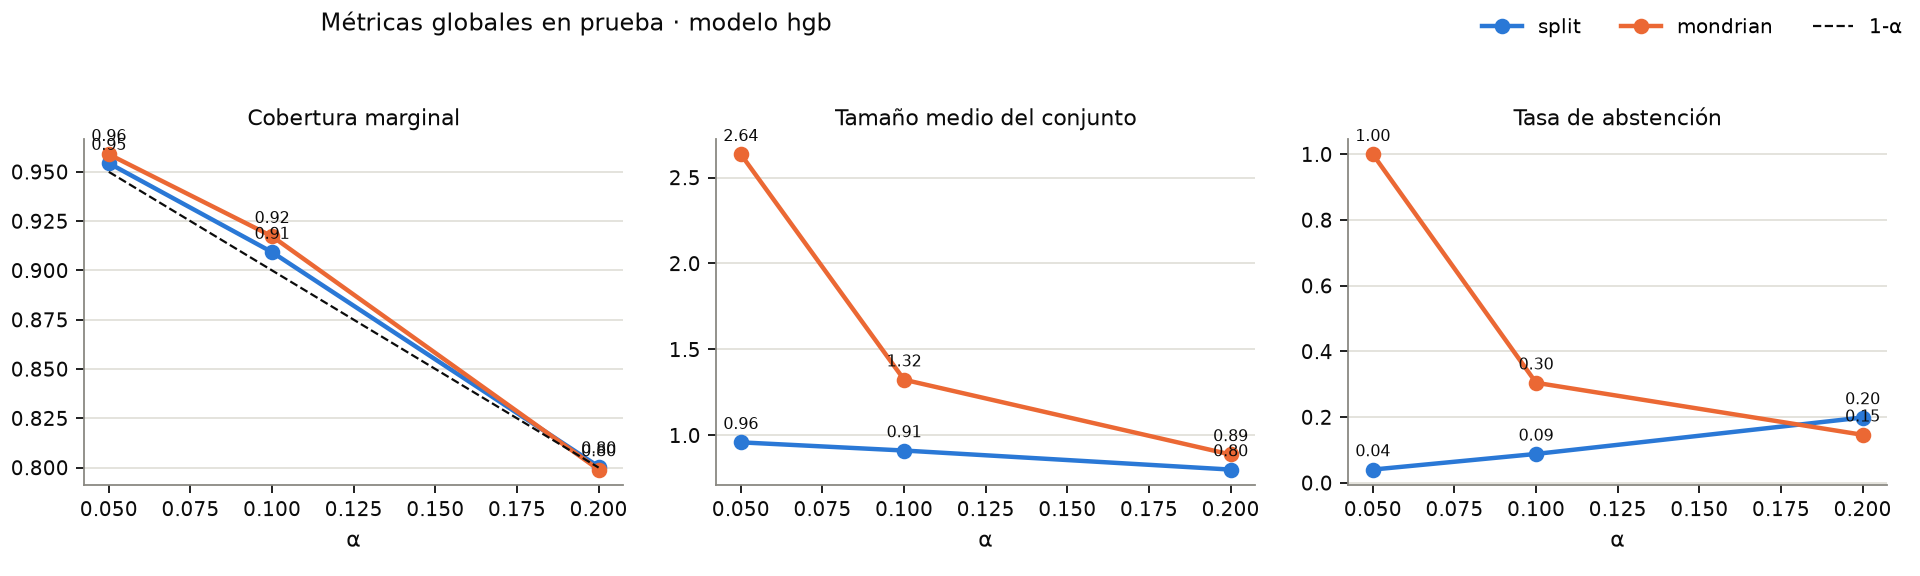

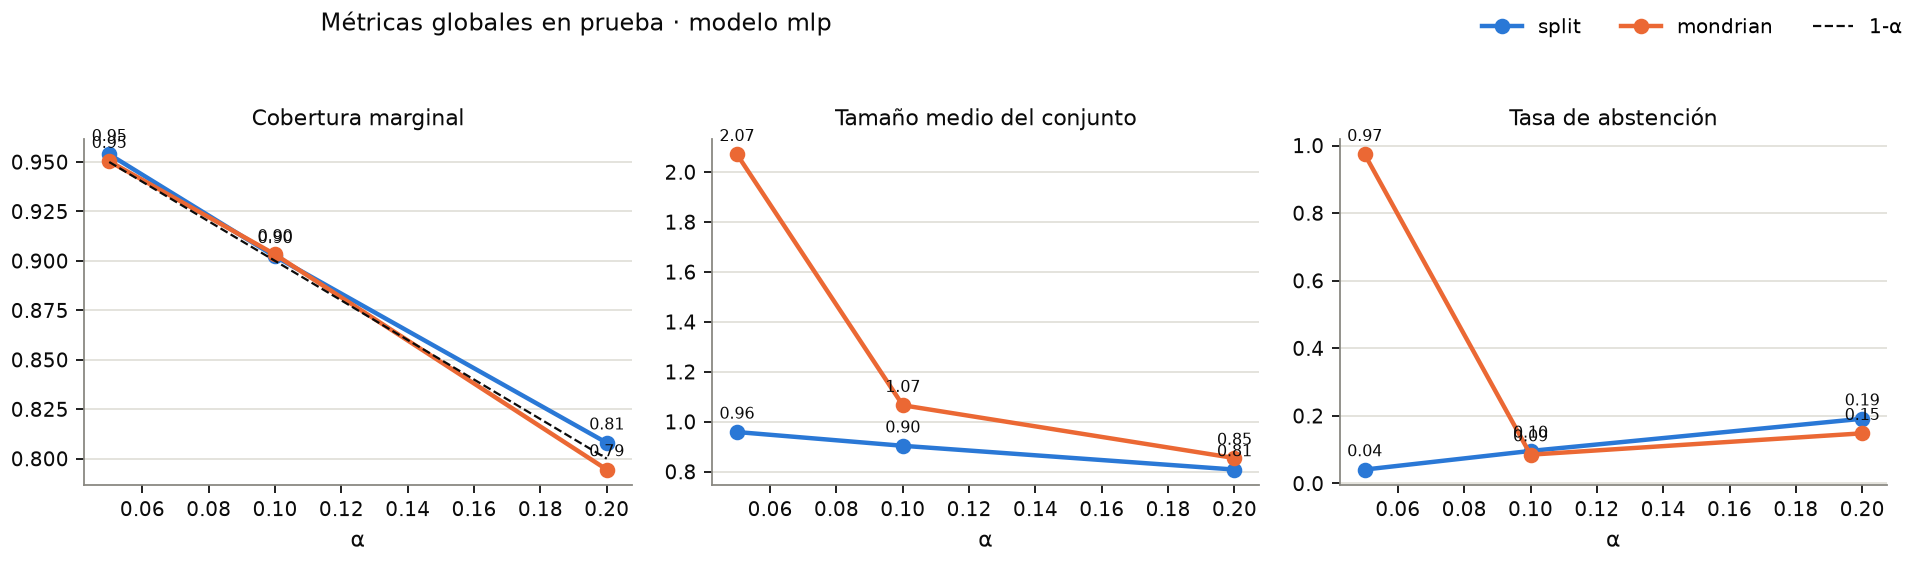

In [11]:
for model in metrics["model"].unique():
    display(Image(filename=str(FIG / f"global_metrics_{model}.png"), width=1100))

## 5. Cobertura por clase

La cobertura marginal puede cumplirse ignorando las clases minoritarias. Mondrian calibra
un umbral por clase y por eso las cubre; el precio es el tamaño del conjunto.

In [12]:
by_class = pd.read_csv(RUN / "metrics_by_class.csv")
by_class.pivot_table(index=["model", "variant", "alpha"], columns="class", values="coverage")

class                    HDF  Normal     OSF     PWF     TWF
model variant  alpha                                        
hgb   mondrian 0.05   0.9524  0.9580  1.0000  1.0000  1.0000
               0.10   0.9524  0.9150  1.0000  1.0000  1.0000
               0.20   0.9524  0.7952  1.0000  0.8421  0.7778
      split    0.05   0.7143  0.9772  0.2353  0.0000  0.0000
               0.10   0.1429  0.9383  0.0588  0.0000  0.0000
               0.20   0.0000  0.8274  0.0588  0.0000  0.0000
mlp   mondrian 0.05   1.0000  0.9487  1.0000  1.0000  1.0000
               0.10   0.9524  0.9010  1.0000  0.9474  1.0000
               0.20   0.7619  0.7942  0.7059  0.9474  0.7778
      split    0.05   0.5714  0.9689  0.4118  0.7895  0.0000
               0.10   0.3333  0.9217  0.1765  0.6316  0.0000
               0.20   0.0476  0.8310  0.0000  0.4211  0.0000

In [13]:
by_class.pivot_table(index=["model", "variant", "alpha"], columns="class", values="mean_set_size")

class                    HDF  Normal     OSF     PWF     TWF
model variant  alpha                                        
hgb   mondrian 0.05   2.6667  2.6366  2.7059  2.2632  2.8889
               0.10   1.4762  1.3069  2.0000  2.0526  1.7778
               0.20   1.0476  0.8745  1.5294  1.5263  1.0000
      split    0.05   0.7143  0.9782  0.2353  0.0526  0.7778
               0.10   0.1429  0.9383  0.0588  0.0000  0.5556
               0.20   0.0000  0.8274  0.0588  0.0000  0.1111
mlp   mondrian 0.05   2.1905  2.0648  2.6471  2.1053  2.0000
               0.10   1.1429  1.0560  2.0000  1.0000  1.4444
               0.20   0.7619  0.8533  1.0000  1.0000  0.7778
      split    0.05   0.6190  0.9705  0.4118  0.8421  0.5556
               0.10   0.3333  0.9217  0.1765  0.6842  0.2222
               0.20   0.0476  0.8310  0.0000  0.4737  0.0000

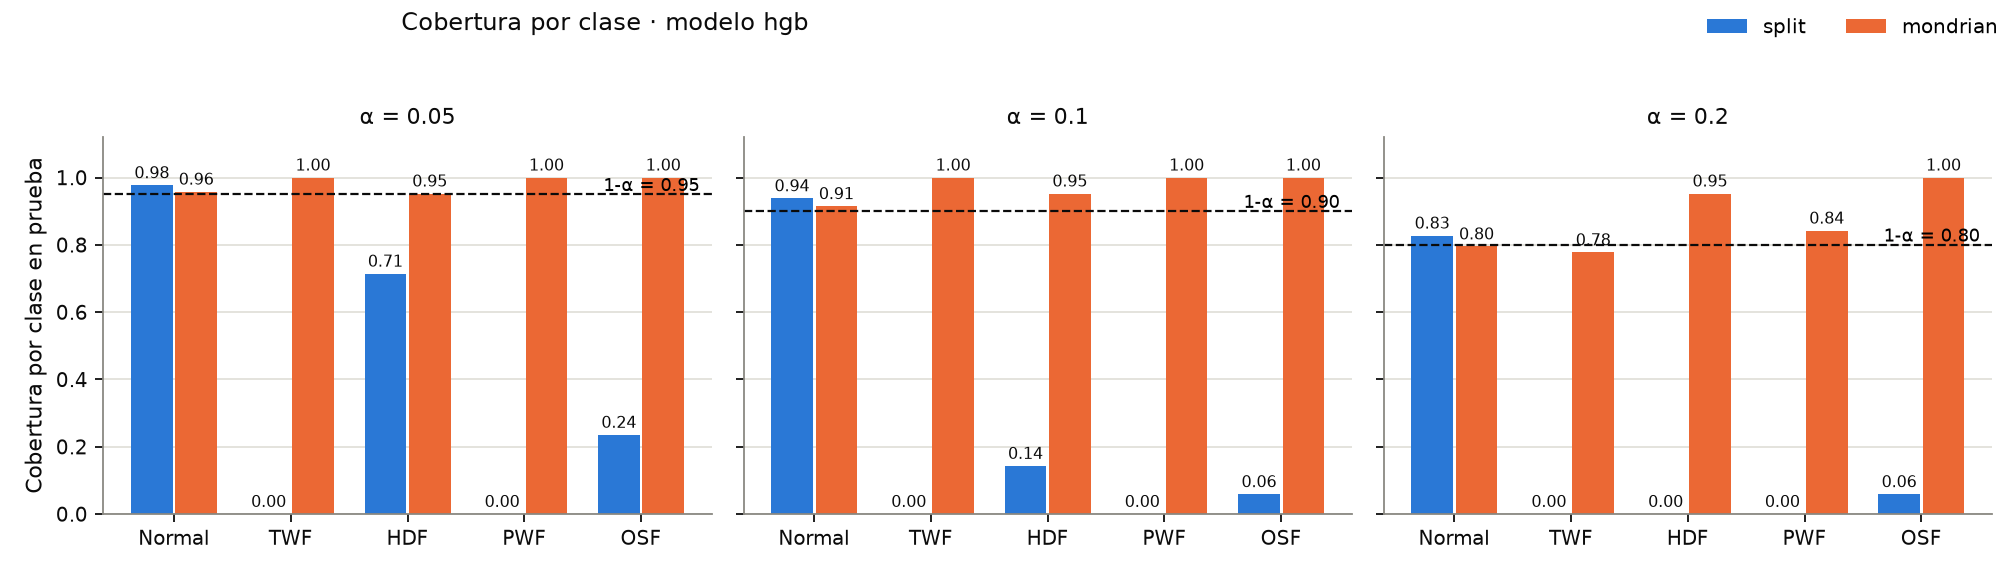

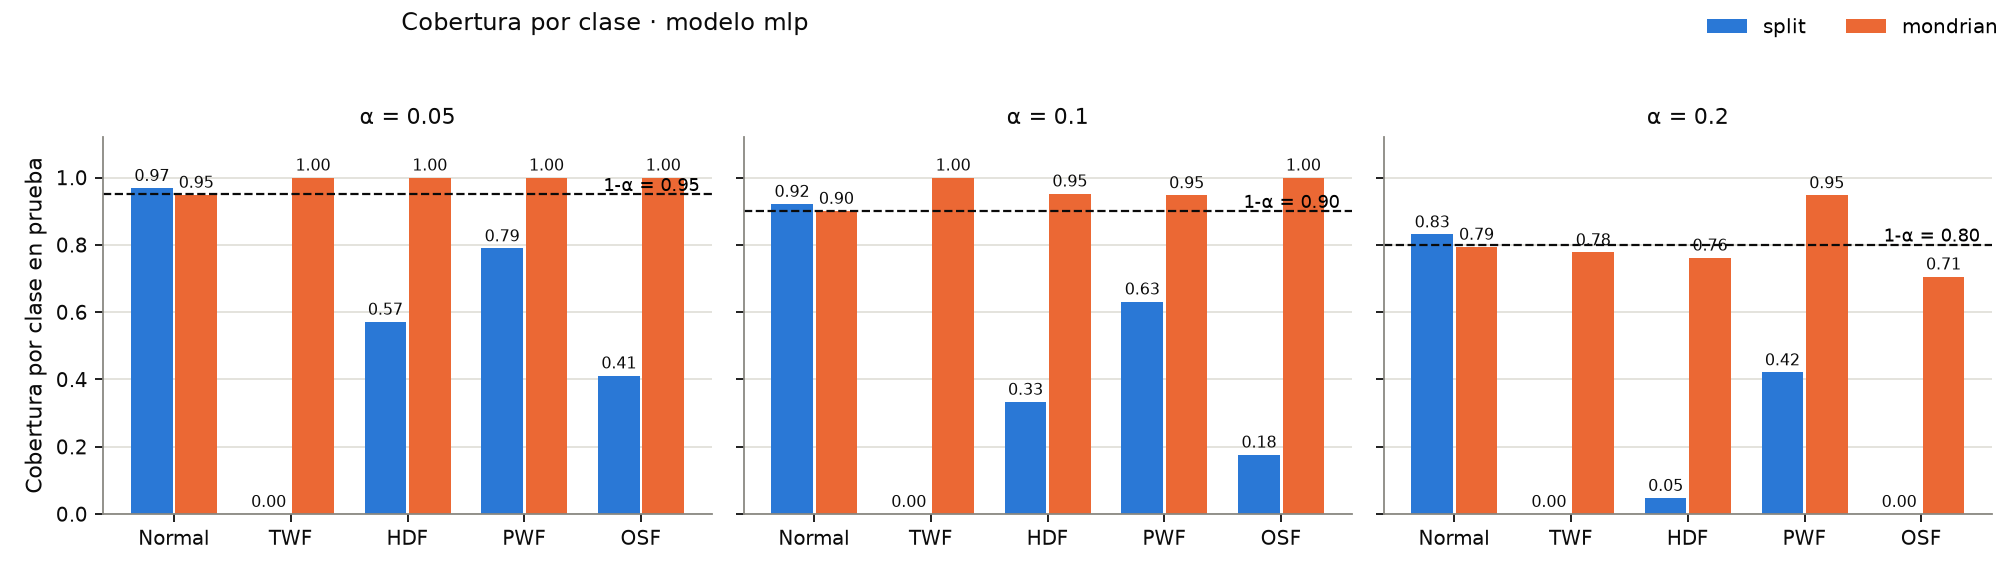

In [14]:
for model in metrics["model"].unique():
    display(Image(filename=str(FIG / f"coverage_by_class_{model}.png"), width=1100))

## 6. Umbrales calibrados

In [15]:
thresholds = pd.read_csv(RUN / "thresholds.csv")
thresholds.pivot_table(index=["model", "variant", "alpha"], columns="class", values="threshold").style.format("{:.3e}")

## 7. Errores entre las decisiones automáticas

La cobertura no garantiza la exactitud condicionada a decidir de forma automática. Se mide
aparte: fracción de conjuntos de tamaño 1 cuya única clase no es la verdadera.

In [16]:
errors = pd.read_csv(RUN / "automatic_errors.csv")
errors[errors["alpha"] == 0.10].pivot_table(index=["model", "variant"], columns="class", values=["automatic", "errors"], aggfunc="sum")

automatic                    errors                   
class                HDF Normal OSF PWF TWF    HDF Normal OSF PWF TWF
model variant                                                        
hgb   mondrian        14   1367   3   0   3      1     81   0   0   0
      split            3   1810   1   0   5      0      0   0   0   5
mlp   mondrian        17   1781   2  19   6      0    149   0   1   0
      split            7   1778   3  13   2      0      0   0   1   2

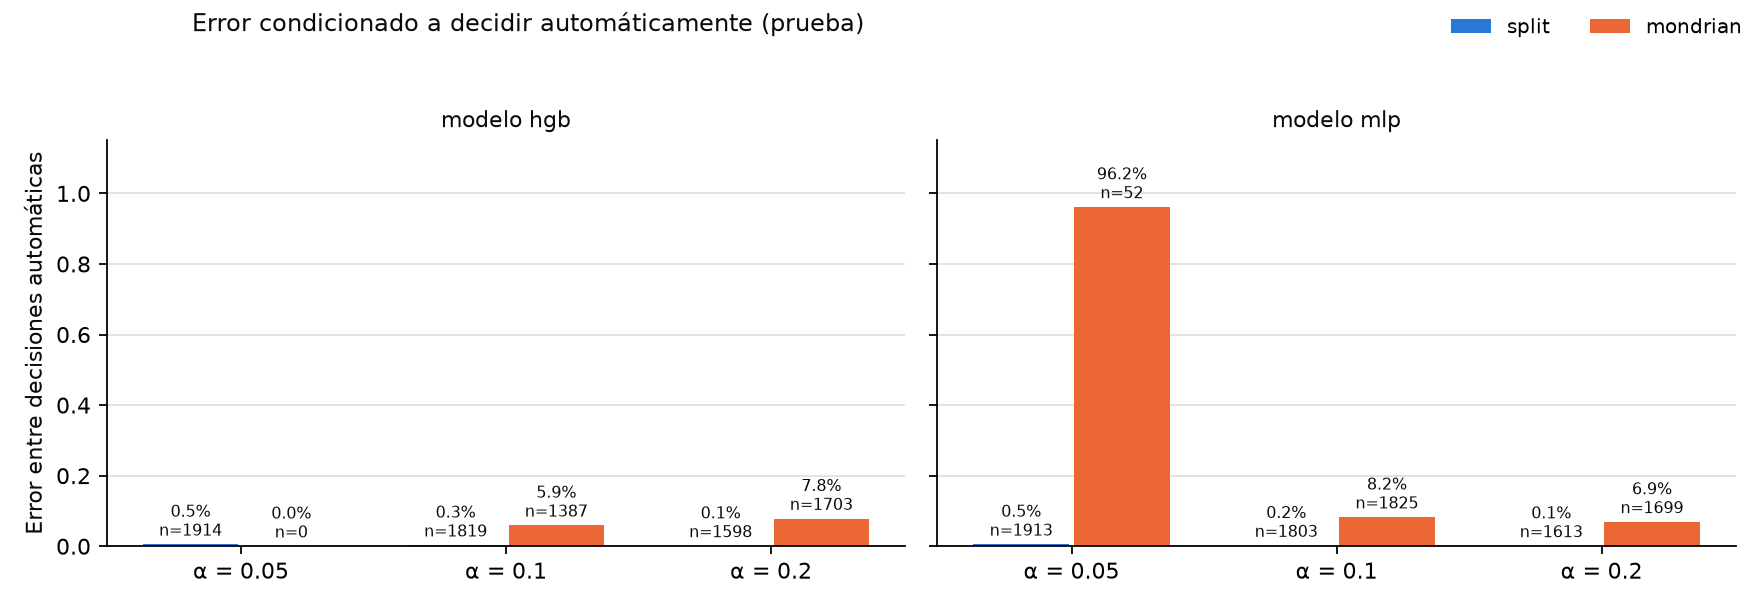

guardada en artifacts\run_2026-09-11_seed42\figures\automatic_error_rate.png


In [17]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, model in zip(axes, metrics["model"].unique()):
    sub = metrics[metrics["model"] == model].sort_values("alpha")
    x = np.arange(sub["alpha"].nunique())
    for offset, (variant, color) in enumerate((("split", BLUE), ("mondrian", ORANGE))):
        rows = sub[sub["variant"] == variant]
        values = rows["automatic_error_rate"].fillna(0).to_numpy()
        bars = ax.bar(x + (offset - 0.5) * 0.38, values, 0.36, color=color, label=variant)
        for bar, value, count in zip(bars, values, rows["automatic_count"]):
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.1%}\nn={count}", ha="center", va="bottom", fontsize=7, color=INK)
    ax.set_xticks(x, [f"α = {a}" for a in sorted(sub["alpha"].unique())])
    ax.set_title(f"modelo {model}", fontsize=10, color=INK)
    ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("Error entre decisiones automáticas", color=INK)
axes[0].set_ylim(0, 1.15)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=9, loc="upper right", ncol=2)
fig.suptitle("Error condicionado a decidir automáticamente (prueba)", fontsize=11, color=INK, x=0.3)
fig.tight_layout(rect=(0, 0, 1, 0.94))
out = FIG / "automatic_error_rate.png"
fig.savefig(out, dpi=160)
plt.close(fig)
display(Image(filename=str(out), width=1000))
print("guardada en", out.relative_to(ROOT))

## 8. Segundo clasificador: MLP en GPU

Traza por época al estilo del hackatón 3 y comparación CPU frente a GPU al estilo del
ejercicio de la semana 3. Los tiempos son mediciones de la sesión que generó la ejecución.

,paso,loss_antes,grad_norm,change_norm,train_accuracy
0,1,1.1035,1.4319,1.2290,0.9669
1,2,0.3862,0.7766,1.0101,0.9669
2,3,0.2197,0.1671,0.4196,0.9669
49,50,0.0455,0.1563,0.1193,0.9862
99,100,0.0323,0.1784,0.1063,0.9902
199,200,0.0209,0.1822,0.1025,0.9946


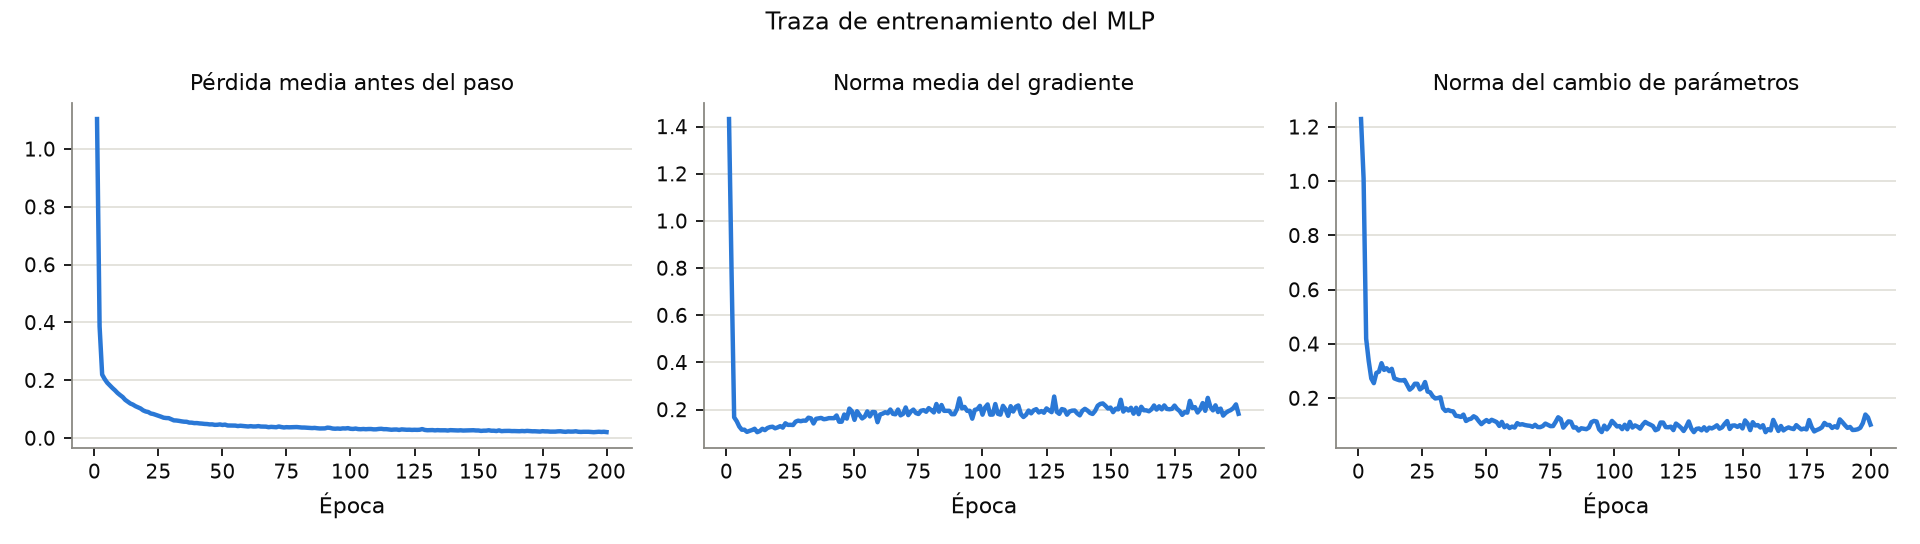

,class,support,accuracy_before,accuracy_after
0,HDF,53,0.0000,0.9057
1,Normal,4821,0.8490,0.9996
2,OSF,42,0.0000,1.0000
3,PWF,47,0.0000,1.0000
4,TWF,23,0.2174,0.1304


línea base mayoritaria en entrenamiento: 0.9669


In [18]:
mlp_dir = RUN / "models" / "mlp"
if mlp_dir.exists():
    trace = pd.read_csv(mlp_dir / "training_trace.csv")
    display(trace.iloc[[0, 1, 2, 49, 99, 199]])
    display(Image(filename=str(FIG / "training_trace_mlp.png"), width=1100))
    display(pd.read_csv(mlp_dir / "train_report.csv"))
    print("línea base mayoritaria en entrenamiento:", round(manifest["mlp"]["majority_baseline_train"], 4))
else:
    print("Esta ejecución no incluye el MLP.")

In [19]:
if (mlp_dir / "benchmark_devices.csv").exists():
    display(pd.read_csv(mlp_dir / "benchmark_devices.csv").drop(columns="muestras_ms"))
    display(pd.read_csv(mlp_dir / "benchmark_parameters.csv"))
    display(pd.read_csv(mlp_dir / "benchmark_transfer.csv").drop(columns="muestras_ms"))
    pd.Series(manifest["mlp"]["entorno"]).to_frame("entorno")

,device,epocas,repeticiones,mediana_ms,min_ms,max_ms,loss_inicial,loss_final,loss_finita,exactitud_final_train
0,cpu,200,3,4347.2788,4102.8057,4397.8530,1.1035,0.0209,True,0.9944
1,cuda,200,3,6380.7183,6244.2647,6386.3436,1.1035,0.0209,True,0.9946


,device,referencia,parametros_cercanos,max_diferencia_abs_parametros,probabilidades_cercanas,max_diferencia_abs_probabilidades,misma_clase_predicha,atol,rtol
0,cpu,cpu,True,0.0000,True,0.0000,1.0000,0.0001,0.0001
1,cuda,cpu,False,0.0269,False,0.0411,0.9998,0.0001,0.0001


,device,modo,n_filas,mediana_ms,min_ms,max_ms
0,cuda,residente,1995,0.1127,0.1052,0.2140
1,cuda,con_transferencias,1995,0.2398,0.2238,2.5673


## 9. Verificación: reconstruir las métricas desde las probabilidades guardadas

Con `probabilities_test.csv` y `thresholds.csv` se reconstruyen los conjuntos y se comparan
las métricas con `metrics.csv`. Si coinciden, el informe es trazable hasta las
probabilidades del modelo.

In [20]:
from conformal_fault_inference_with_abstention.contracts import PredictionSets

rows = []
for model in metrics["model"].unique():
    pt = pd.read_csv(RUN / "models" / model / "probabilities_test.csv", index_col=0)
    cls = np.array([c[2:] for c in pt.columns if c.startswith("p_")])
    P = pt[[f"p_{c}" for c in cls]].to_numpy()
    y = pt["y_true"].to_numpy(dtype=str)
    for (variant, a), th in thresholds[thresholds["model"] == model].groupby(["variant", "alpha"]):
        t = th.set_index("class").loc[cls, "threshold"].to_numpy()
        report = evaluate_sets(y, PredictionSets(cls, (1 - P) <= t))
        rows.append({"model": model, "variant": variant, "alpha": a,
                     "cov_reconstruida": report.marginal_coverage, "size_reconstruido": report.mean_set_size,
                     "err_auto_reconstruido": report.automatic_error_rate})
check = metrics.merge(pd.DataFrame(rows), on=["model", "variant", "alpha"])
ok = (np.allclose(check["marginal_coverage"], check["cov_reconstruida"])
      and np.allclose(check["mean_set_size"], check["size_reconstruido"])
      and np.allclose(check["automatic_error_rate"].fillna(-1), check["err_auto_reconstruido"].fillna(-1)))
print("Métricas reconstruidas coinciden con metrics.csv:", ok)
check[["model", "variant", "alpha", "marginal_coverage", "cov_reconstruida", "mean_set_size", "size_reconstruido"]]

Métricas reconstruidas coinciden con metrics.csv: True


,model,variant,alpha,marginal_coverage,cov_reconstruida,mean_set_size,size_reconstruido
0,hgb,split,0.05,0.9544,0.9544,0.9594,0.9594
1,hgb,mondrian,0.05,0.9589,0.9589,2.6351,2.6351
2,hgb,split,0.10,0.9093,0.9093,0.9118,0.9118
3,hgb,mondrian,0.10,0.9173,0.9173,1.3238,1.3238
4,hgb,split,0.20,0.8005,0.8005,0.8010,0.8010
5,hgb,mondrian,0.20,0.7990,0.7990,0.8887,0.8887
6,mlp,split,0.05,0.9539,0.9539,0.9589,0.9589
7,mlp,mondrian,0.05,0.9504,0.9504,2.0712,2.0712
8,mlp,split,0.10,0.9023,0.9023,0.9038,0.9038
9,mlp,mondrian,0.10,0.9033,0.9033,1.0662,1.0662


## 10. Lectura

- En esta partición, las coberturas marginales quedan a menos de 0.02 del nominal con ambos
  modelos. Es consistente con la garantía, que se sostiene bajo intercambiabilidad; una
  partición la ilustra, no la demuestra.
- Split conformal cumple la cobertura marginal sin cubrir TWF ni PWF. Mondrian lleva las
  cuatro fallas a cobertura 0.95 o más con α ≤ 0.10, a cambio de conjuntos más grandes.
- Entre las decisiones automáticas, Mondrian comete falsas alarmas (5.9 % hgb, 8.2 % MLP con
  α = 0.10) y split omite fallas (0.3 %, todas fallas enviadas como Normal). Cuál conviene
  depende de costos que este proyecto no fija.
- El MLP en GPU no fue más rápido que en CPU: el modelo es demasiado pequeño para que el
  cálculo supere el costo de lanzar kernels.

Detalles, referencias y limitaciones en [RESULTADOS.md](../RESULTADOS.md).